# EXPLORATORY DATA ANALYSIS 

In [1]:
import pandas as pd 
df=pd.read_csv("Cardiotocographic.csv")

In [3]:
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [4]:
df.shape

(2126, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [6]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2105.000000,2106.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,133.343598,0.003219,0.009894,0.004391,0.001895,0.000003,0.000175,46.995984,1.364378,10.285964,8.284887,70.429260,0.316371,1.304507
std,11.270154,0.004391,0.067540,0.003340,0.003343,0.000142,0.000840,18.813973,1.173632,21.205041,7.772858,42.931822,0.645622,0.644619
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005650,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.900000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


Based on the statistical summary and the data tables you provided, here are the 5 most critical insights for your assignment:

Extreme Data Noise (Negative Values): Several features that should strictly be positive or zero (like AC, FM, and ASTV) contain negative values, such as a minimum of -63 for ASTV. These are clear data entry errors that must be cleaned, as biological percentages and counts cannot be less than zero.

Severe Class Imbalance: The target variable NSP has a median and 75th percentile of 1.0, meaning the vast majority of the 2,126 cases are "Normal." This mathematically confirms that Classes 2 (Suspect) and 3 (Pathologic) are rare, which will make model training challenging.

Significant Clinical Outliers: While the average fetal heart rate (LB) is a healthy 133 bpm, the range is extreme, spanning from 51.8 to 214. These outliers represent severe medical conditions (Bradycardia and Tachycardia) and are the primary indicators of fetal distress.

High Right-Skewness in Pathology Markers: For features like ALTV, the median is 0.0 but the mean is 10.28. This indicates that most fetuses show 0% abnormal long-term variability, while a small "sick" group has very high values that pull the average upward.


Scale Variance Requiring Normalization: There is a massive disparity in scales across the 14 features; for example, Width has a standard deviation of 42.93, while DS is nearly 0. You must mention that Feature Scaling is required to prevent large-scale variables from dominating your analysis.

In [7]:
df.columns

Index(['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Tendency', 'NSP'],
      dtype='str')

In [8]:
df.isnull()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2122,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2123,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2124,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [9]:
df.isnull().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(2)

In [23]:
df

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,73.0,0.5,43.000000,2.4,64.0,0.999926,2.000000
1,132.000000,0.006380,0.000000,0.006380,0.003190,0.0,0.0,17.0,2.1,0.000000,10.4,130.0,0.000000,1.000000
2,133.000000,0.003322,0.000000,0.008306,0.003322,0.0,0.0,16.0,2.1,0.000000,13.4,130.0,0.000000,1.000000
3,134.000000,0.002561,0.000000,0.007742,0.002561,0.0,0.0,16.0,2.4,0.000000,23.0,117.0,1.000000,1.000000
4,131.948232,0.006515,0.000000,0.008143,0.000000,0.0,0.0,16.0,2.4,0.000000,19.9,117.0,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.000000,0.000000,0.961268,0.007426,0.000000,0.0,0.0,79.0,0.2,25.000000,7.2,40.0,0.000000,2.000000
2122,140.000000,0.000775,0.000000,0.006979,0.000000,0.0,0.0,78.0,0.4,22.000000,7.1,66.0,1.000000,2.000000
2123,140.000000,0.000980,0.000000,0.006863,0.000000,0.0,0.0,79.0,0.4,20.000000,6.1,67.0,1.000000,1.990464
2124,140.000000,0.000679,0.000000,0.006110,0.000000,0.0,0.0,78.0,0.4,27.000000,7.0,66.0,1.000000,2.000000


Text(0.5, 1.0, 'Distribution of Fetal Heart Rate Baseline (LB)')

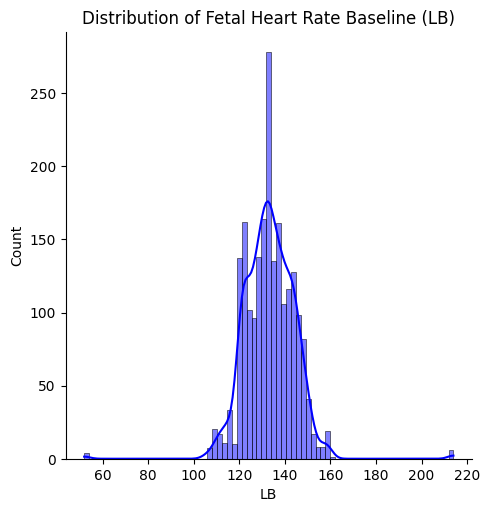

In [17]:
import seaborn as sns 
import matplotlib.pyplot as plt 
sns.displot(df['LB'], kde=True, color='blue')
plt.title('Distribution of Fetal Heart Rate Baseline (LB)')

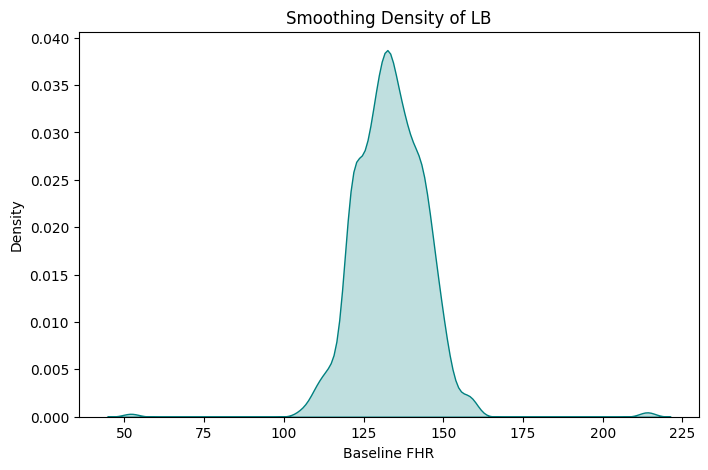

In [19]:
plt.figure(figsize=(8, 5))
sns.kdeplot(df['LB'], fill=True, color='teal')
plt.title('Smoothing Density of LB')
plt.xlabel('Baseline FHR')
plt.show()

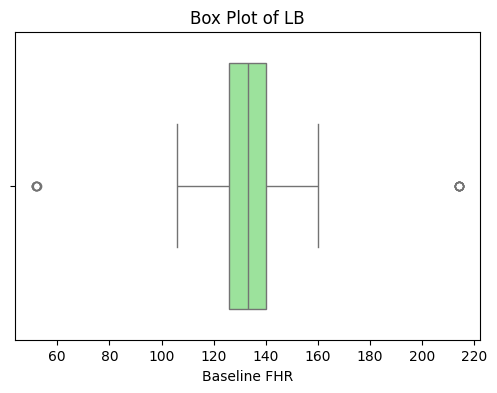

In [18]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['LB'], color='lightgreen')
plt.title('Box Plot of LB')
plt.xlabel('Baseline FHR')
plt.show()

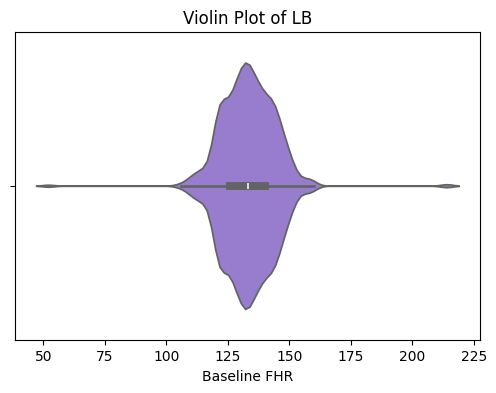

In [21]:
plt.figure(figsize=(6, 4))
sns.violinplot(x=df['LB'], color='mediumpurple')
plt.title('Violin Plot of LB')
plt.xlabel('Baseline FHR')
plt.show()

Distributions

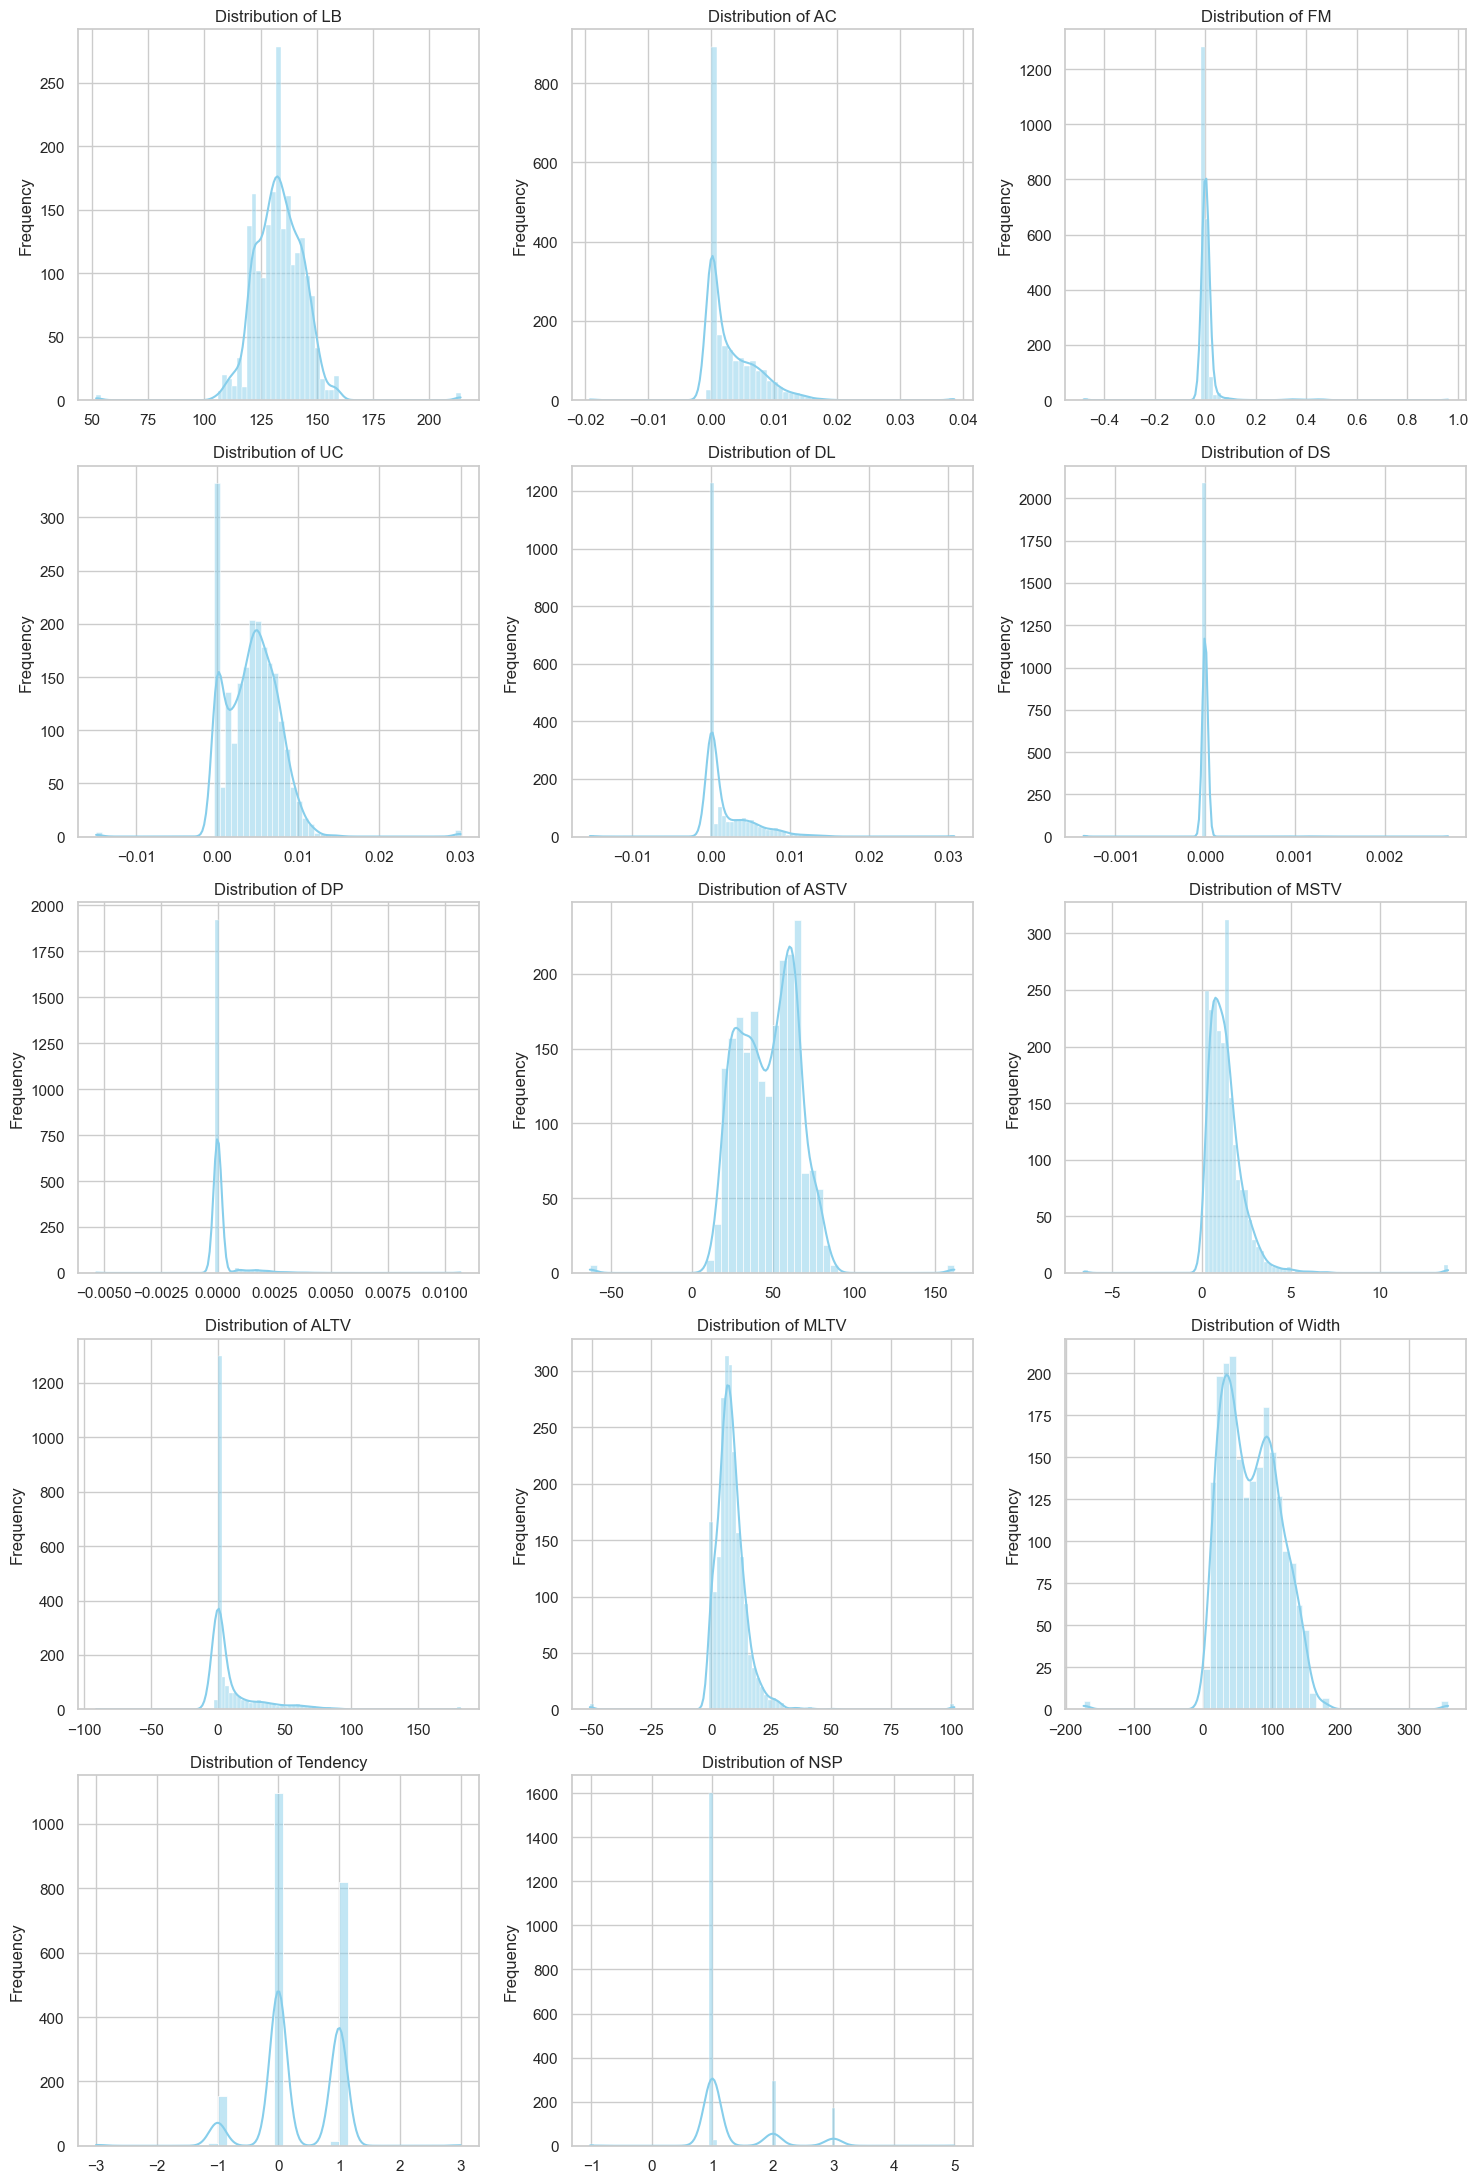

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

cols = df.columns

plt.figure(figsize=(15, 22))

for i, col in enumerate(cols):
    plt.subplot(5, 3, i + 1)  
    sns.histplot(df[col], kde=True, color="skyblue")
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel('') 
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Based on the distribution plots provided, here are 7 key insights derived from the shape and spread of the data in your Cardiotocographic assignment:

Physiological Normality of Baseline (LB): The Fetal Heart Rate Baseline (LB) shows a near-normal (Gaussian) distribution centered around 130–140 bpm. This indicates that the majority of the fetuses in the study possess a stable, healthy baseline heart rate as per standard medical benchmarks.

Evidence of Sparse Pathological Markers: Several features like DS (Severe Decelerations), DP (Prolonged Decelerations), and FM (Fetal Movements) show massive spikes at zero. This suggests these events are rare in the general population, but the "long tails" on the right indicate specific high-risk cases that a model must learn to identify.

Bimodal Pattern in ASTV: The distribution for ASTV (Abnormal Short Term Variability) is distinctly bimodal (two peaks). This suggests the dataset contains two hidden subpopulations—likely distinguishing healthy fetuses from those experiencing varying degrees of distress.

Severe Class Imbalance (NSP): The NSP plot shows that Class 1 (Normal) significantly outweighs Classes 2 (Suspect) and 3 (Pathologic). From an analysis standpoint, this means your final model might struggle to predict the "sick" classes unless you use techniques like oversampling or specific evaluation metrics (like F1-score).

Categorical Nature of Tendency: Unlike the continuous heart rate metrics, the Tendency plot shows three discrete spikes at -1, 0, and 1. This indicates that while it is stored as a number, it acts as a categorical or ordinal feature representing the skew of the FHR histogram.

Right-Skewness in UC and AC: Features like UC (Uterine Contractions) and AC (Accelerations) are right-skewed. Most recordings show low activity, but the presence of high values in these areas is often a key differentiator between a reactive (healthy) and non-reactive fetus.

Scale Variance and Outliers: The x-axes vary wildly, from tiny decimals in AC to hundreds in Width. Additionally, several plots show extreme outliers (dots far from the main "hump"). For your assignment, this is a clear sign that you must perform data cleaning (to handle noise) and feature scaling (to ensure fair weighting) before any machine learning.

Boxplots

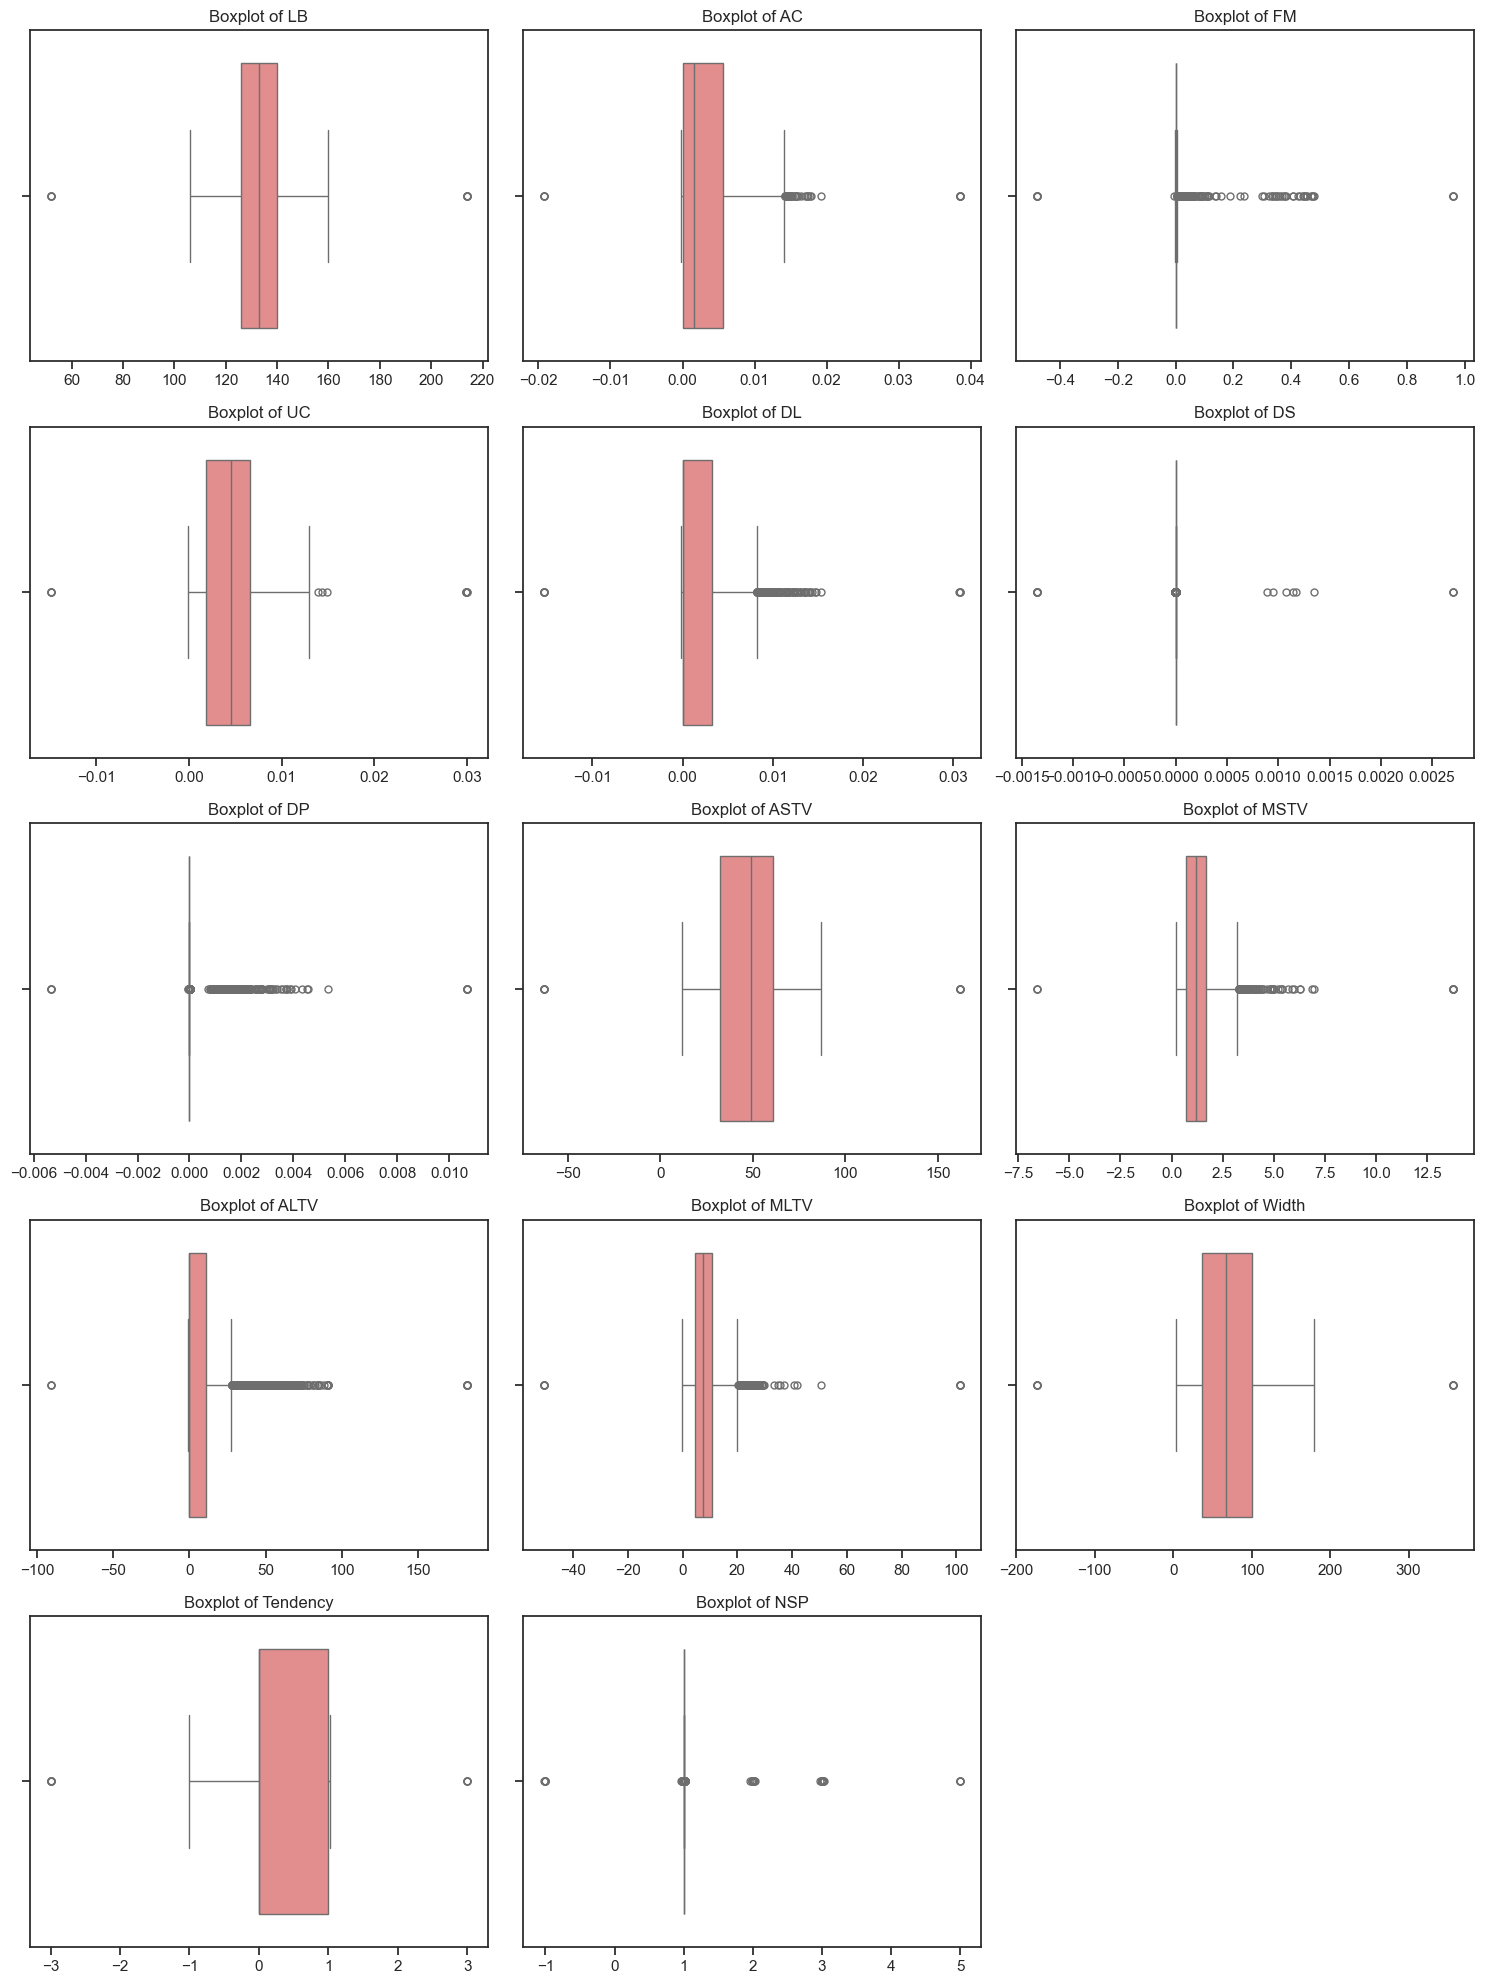

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks")

cols = df.columns

plt.figure(figsize=(15, 20))

for i, col in enumerate(cols):
    plt.subplot(5, 3, i + 1)
    sns.boxplot(x=df[col], color='lightcoral', fliersize=5)
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.xlabel('')

plt.tight_layout()
plt.show()

Based on the boxplots you've provided for the Cardiotocographic dataset, here are 5 valid analytical points for your assignment:

Pervasive Outliers and Data Noise: Almost every feature displays "stray" data points beyond the whiskers, most notably in LB, ASTV, and ALTV. While some represent critical medical conditions (like extreme bradycardia in LB), the presence of negative values in fields like AC, UC, and ASTV confirms significant noise that requires data cleaning before modeling.

Zero-Centered/Sparse Activity: For features such as DS (Severe Decelerations), DP (Prolonged Decelerations), and FM (Fetal Movements), the "box" is nearly invisible or compressed at zero. This indicates that for the majority of the population, these events do not occur, making any non-zero value a statistically significant clinical observation.

Significant Right-Skewness: The majority of the boxes are shifted toward the left side of their respective scales (especially in AC, DL, and ALTV), with long whiskers extending to the right. This confirms that while the "normal" range is low, there is a wide and varied range of elevated values that likely correlate with fetal distress.

High Variability in Signal Width: The Width feature shows one of the largest interquartile ranges (the physical width of the pink box) and the longest whiskers. This suggests that the difference between the minimum and maximum fetal heart rate varies drastically from one patient to another, unlike LB, which remains relatively tightly clustered.

Mathematical Confirmation of Class Imbalance: The boxplot for the target variable NSP shows the median (the line inside the box) and the 75th percentile (the right edge of the box) are both at 1.0. This proves that at least 75% of your dataset consists of "Normal" cases, highlighting a heavy imbalance that could bias a machine learning model toward the majority class.

violinplots

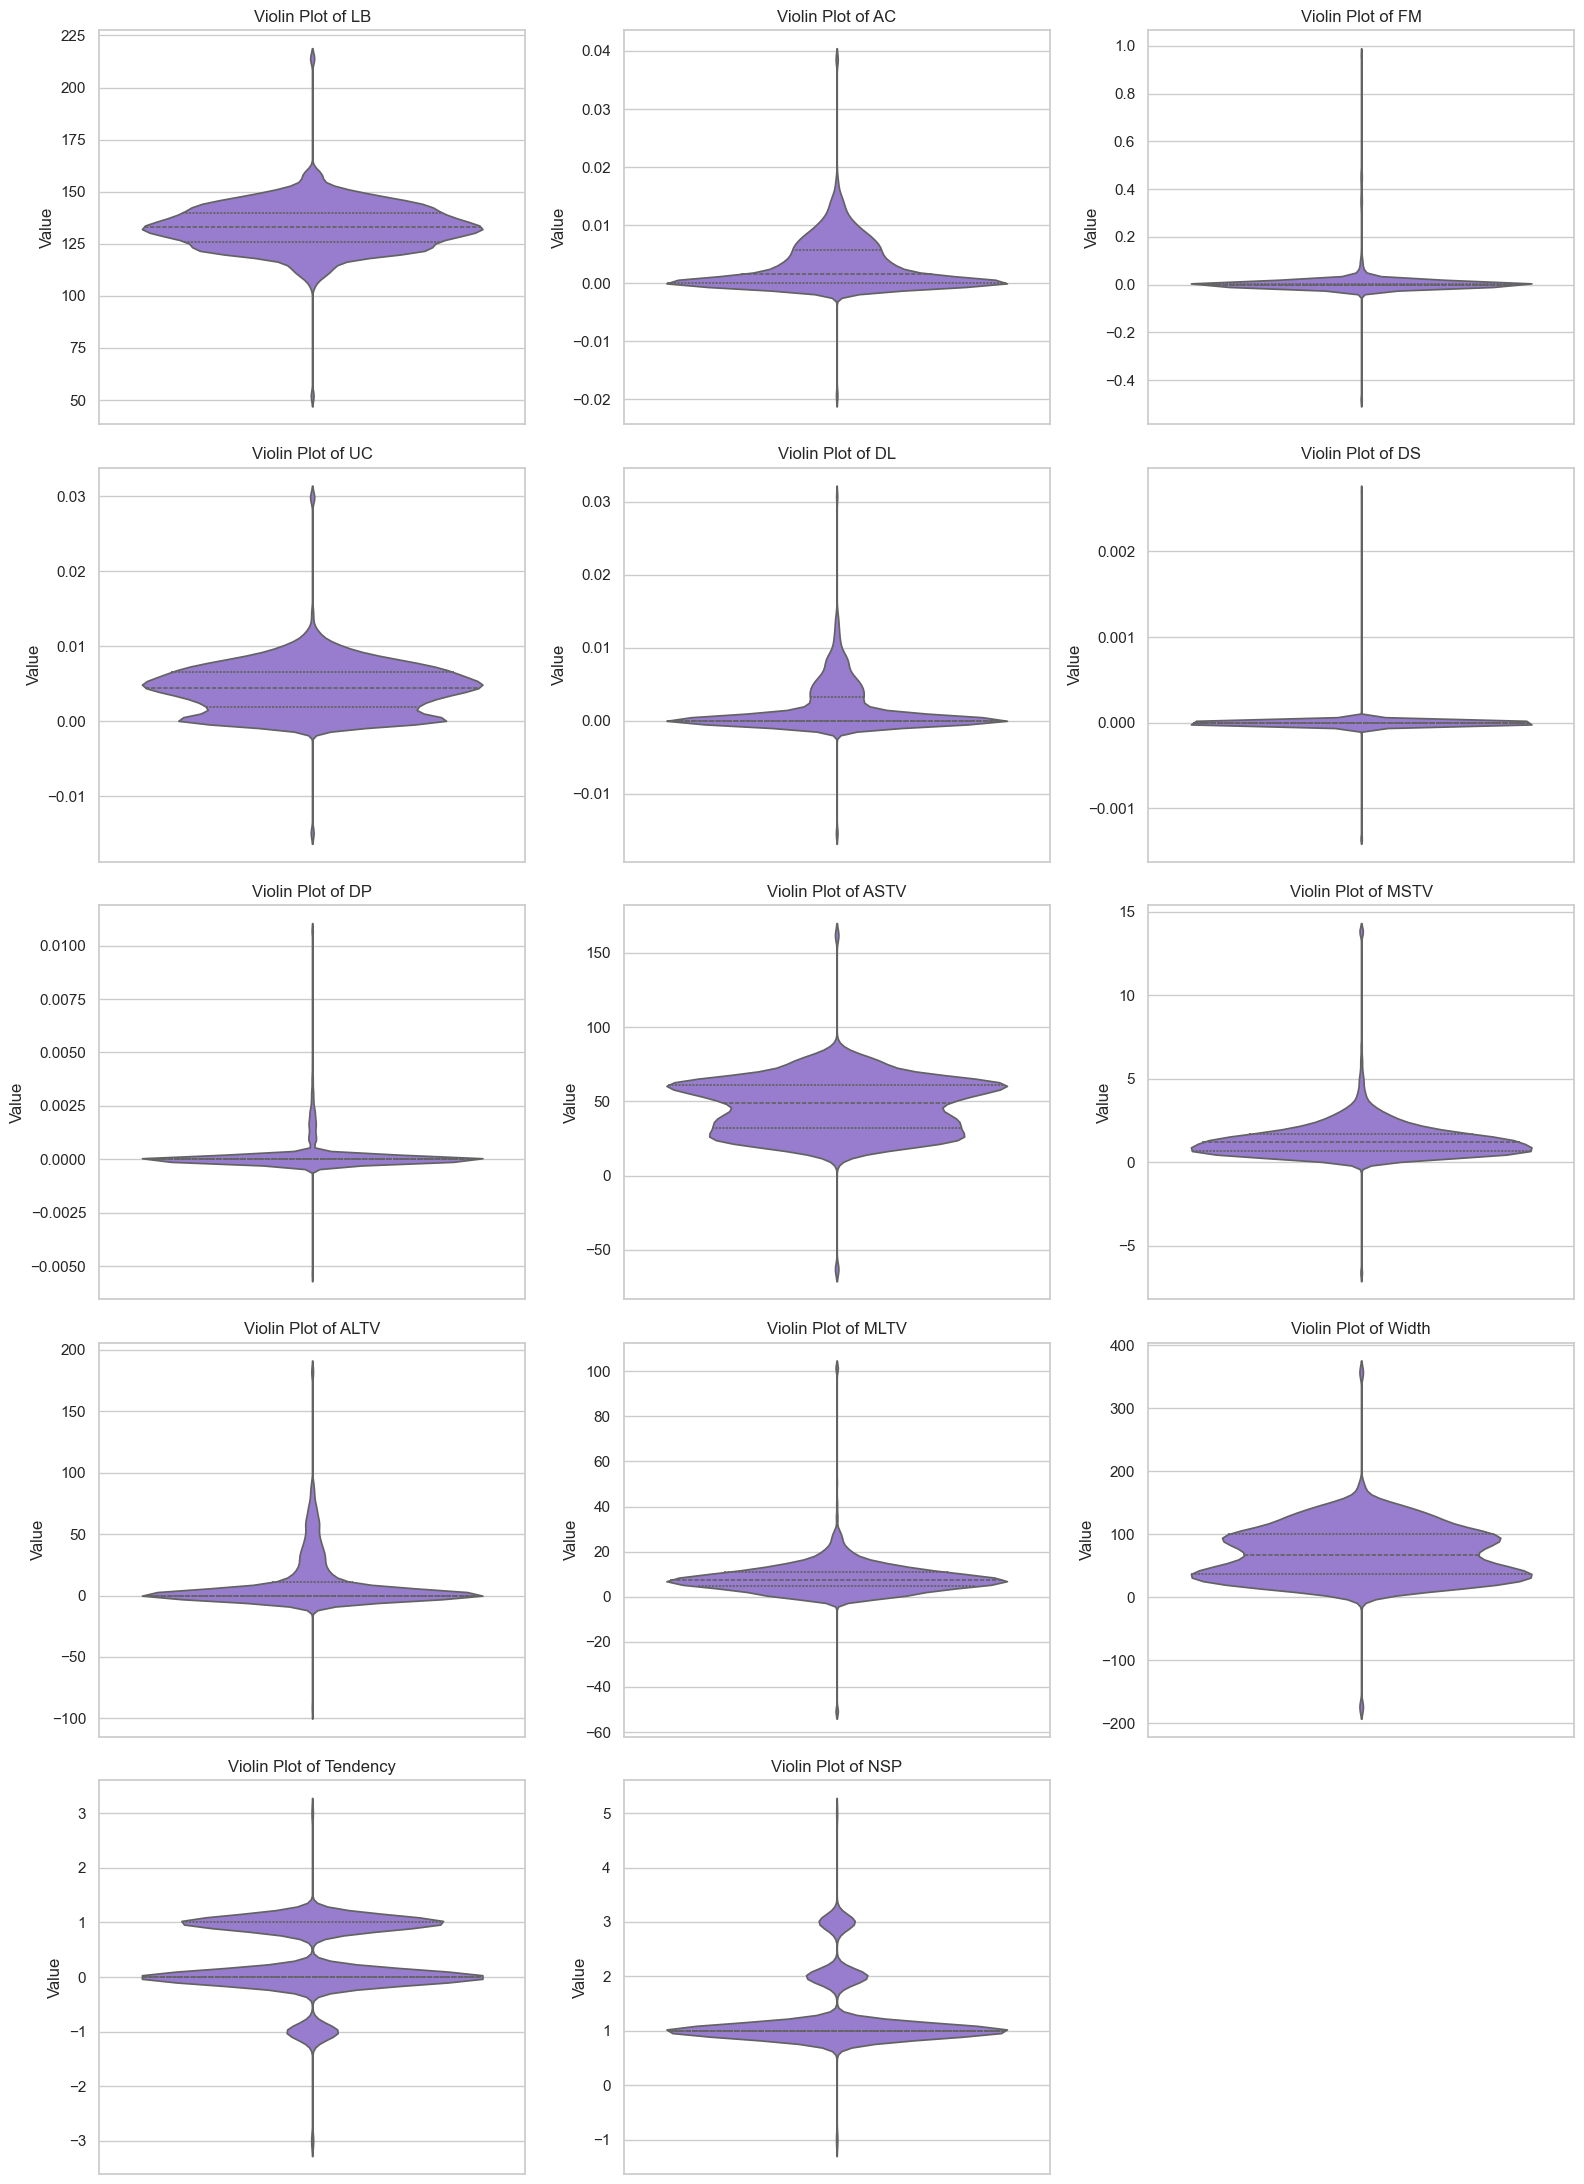

In [ ]:
sns.set_theme(style="whitegrid")

cols = df.columns

plt.figure(figsize=(16, 22))

for i, col in enumerate(cols):
    plt.subplot(5, 3, i + 1)
    sns.violinplot(y=df[col], color="mediumpurple", inner="quartile")
    plt.title(f'Violin Plot of {col}', fontsize=12)
    plt.ylabel('Value')
    plt.xlabel('')

plt.tight_layout()
plt.show()

In [40]:
df.columns

Index(['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Tendency', 'NSP'],
      dtype='str')

pairplots

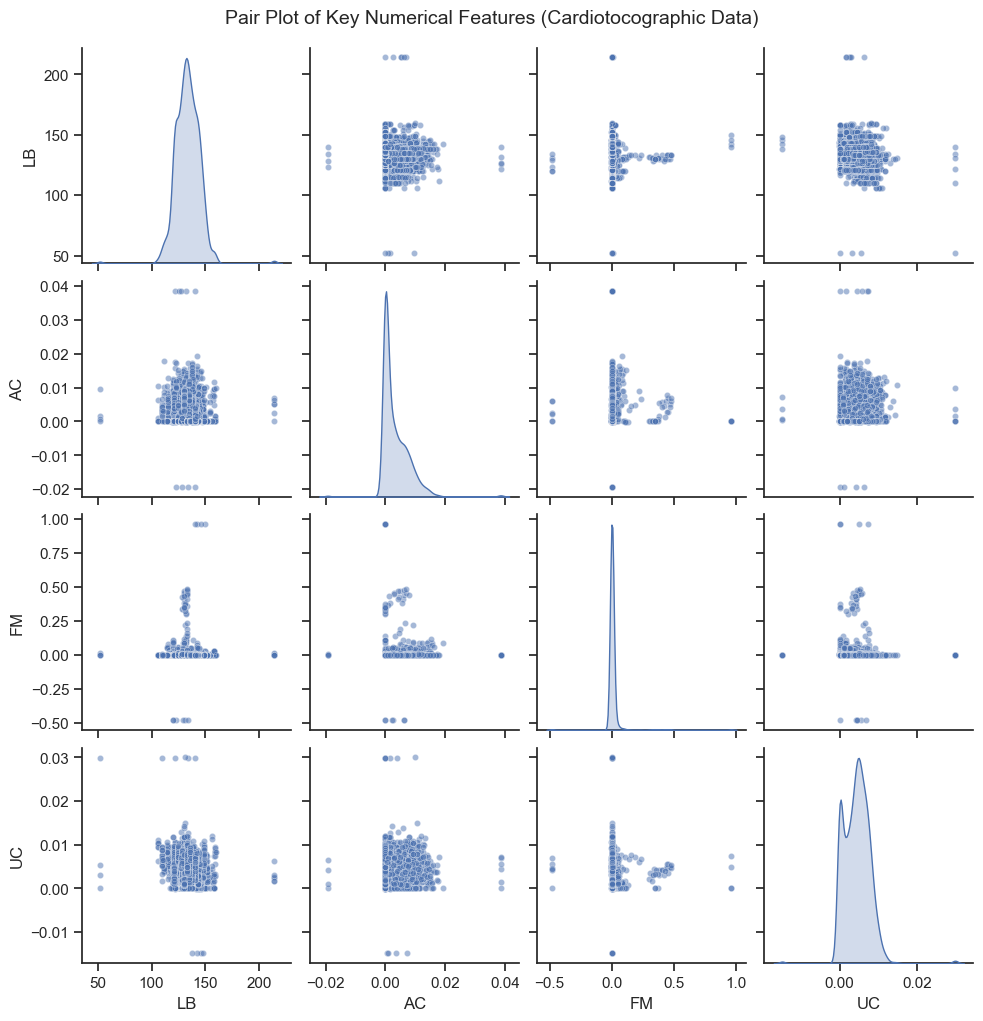

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features_subset = ['LB', 'AC', 'FM', 'UC']

sns.pairplot(df[features_subset], diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})

plt.suptitle('Pair Plot of Key Numerical Features (Cardiotocographic Data)', y=1.02, fontsize=14)
plt.show()

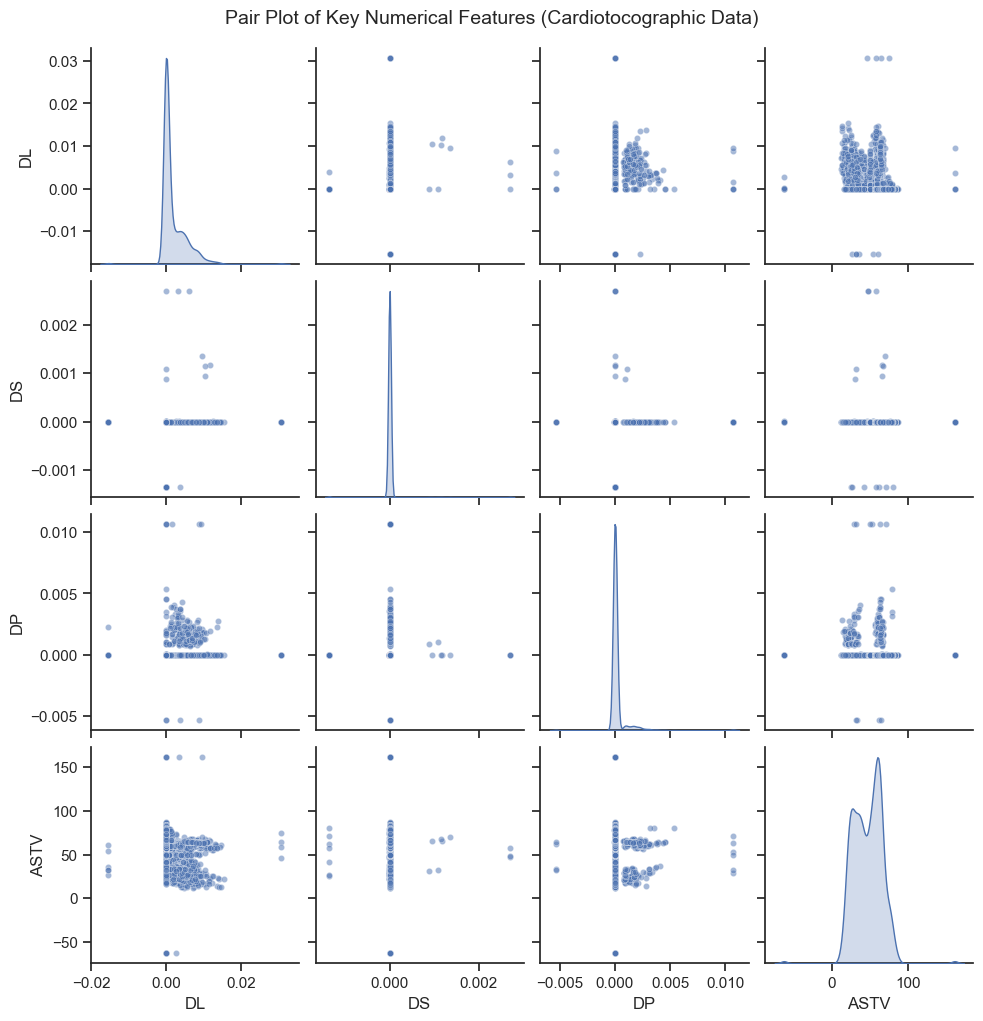

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
features_subset = ['DL', 'DS', 'DP', 'ASTV']

sns.pairplot(df[features_subset], diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})

plt.suptitle('Pair Plot of Key Numerical Features (Cardiotocographic Data)', y=1.02, fontsize=14)
plt.show()

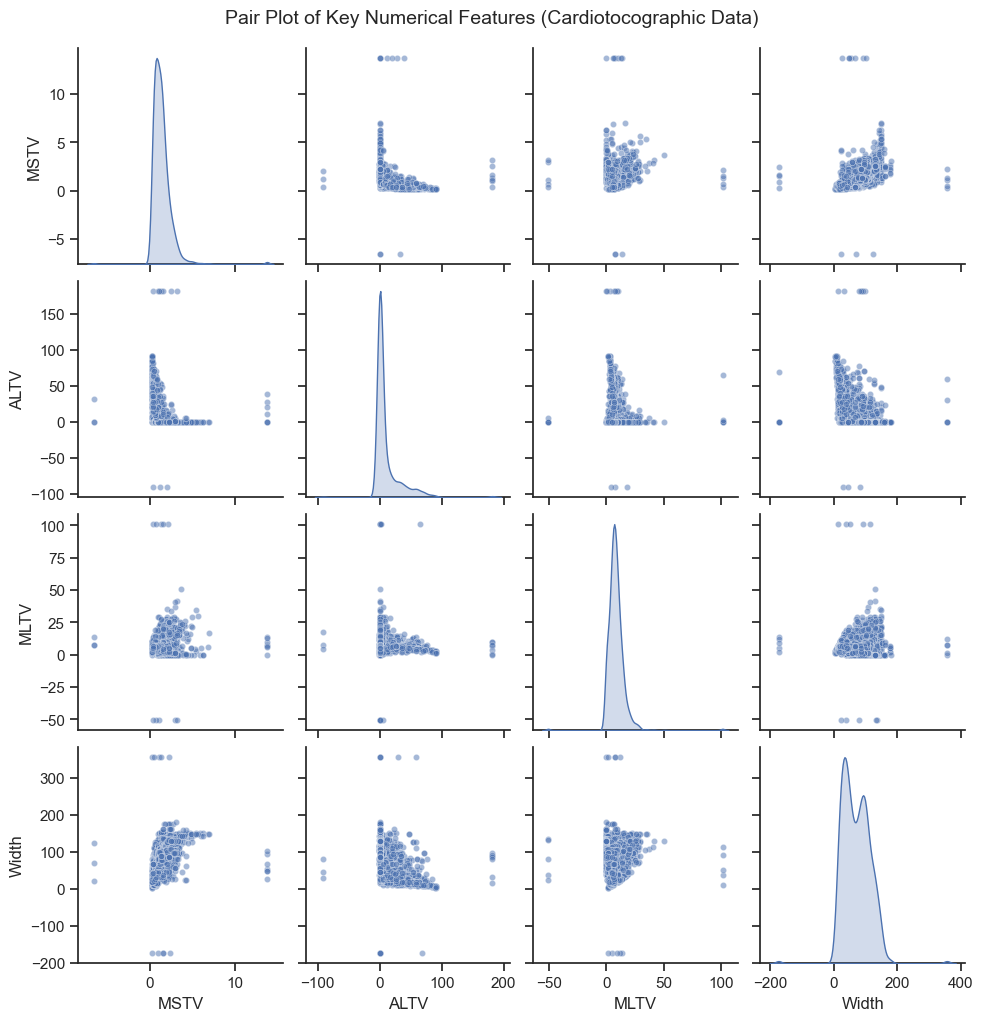

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features_subset = ['MSTV', 'ALTV',
       'MLTV', 'Width']

sns.pairplot(df[features_subset], diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})

plt.suptitle('Pair Plot of Key Numerical Features (Cardiotocographic Data)', y=1.02, fontsize=14)
plt.show()

## Correlation Analysis

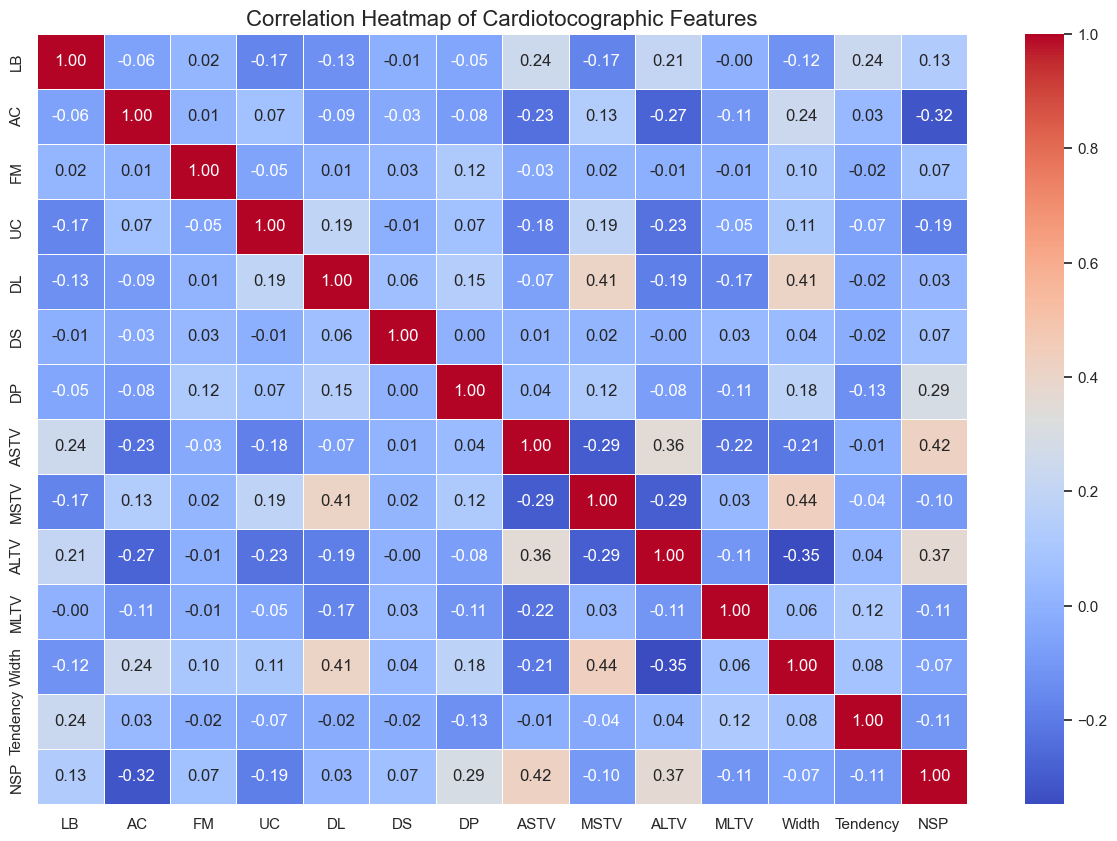

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr()

plt.figure(figsize=(15, 10))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of Cardiotocographic Features', fontsize=16)
plt.show()

Based on the correlation heatmap and statistical data you provided, here are the 5 most critical insights regarding the relationships between variables:

Primary Pathological Drivers (ASTV & ALTV): The strongest positive correlations with the target variable (NSP) are ASTV (0.42) and ALTV (0.37). This implies that as the percentage of abnormal short-term and long-term variability increases, the likelihood of a "Pathologic" diagnosis rises significantly, making these your most important "danger" markers.

Protective Role of Accelerations (AC): There is a strong negative correlation (-0.32) between AC and NSP. This suggests that frequent heart rate accelerations are a key indicator of a "Normal" (healthy) fetus; as accelerations decrease, the clinical risk typically increases.

Warning Signs of Prolonged Decelerations (DP): DP shows a notable positive correlation (0.29) with NSP. While some features like fetal movement (FM) show almost no relationship to health, the presence of prolonged decelerations is a statistically significant "red flag" for fetal distress in this dataset.

The Variability Paradox (ASTV vs. MSTV): There is a negative correlation (-0.29) between ASTV (Abnormal Variability) and MSTV (Mean Variability). This indicates that "healthy" baseline variability and "abnormal" variability are opposing forces; when the heart rate has a healthy, dynamic mean spread, the incidents of abnormal spikes tend to drop.

Feature Redundancy and Modeling Implications: Features like Width and MSTV show a moderate positive correlation (0.44). This suggests they provide overlapping information about the "spread" of the heart rate signal. In your final assignment, you might note that while these are useful for EDA, using both in a simple model might introduce slight redundancy (multicollinearity).

This report summarizes the Exploratory Data Analysis (EDA) performed on the **Cardiotocographic (CTG)** dataset, consisting of 2,126 fetal observations and 14 numerical features.

---

## 1. Executive Summary of Findings
The analysis reveals a dataset primarily composed of healthy fetal observations, but one that is heavily influenced by significant outliers and data integrity issues. While the baseline metrics align with medical norms, the presence of rare pathological markers provides a clear (though imbalanced) roadmap for classification.

## 2. Key Insights

### A. Data Quality and Integrity (Critical)
* **Anomalous Values:** Statistical summaries and boxplots revealed impossible negative values in features like **AC**, **FM**, and **ASTV** (e.g., ASTV minimum of -63). These represent data entry errors or noise that must be addressed.
* **Scale Variance:** Features operate on vastly different scales—from decimals in **AC** (0.003) to hundreds in **LB** (130). This necessitates normalization or standardization before any machine learning modeling.

### B. Distribution and Pathology Markers
* **The "Normal" Baseline:** The **Baseline Fetal Heart Rate (LB)** is well-behaved, following a normal distribution centered at **133 bpm**, which is the clinical standard for a healthy fetus.
    

[Image of a normal distribution curve showing mean and standard deviation]

* **Bimodal Variability:** **ASTV (Abnormal Short-Term Variability)** displays a bimodal distribution. This suggests two distinct patient populations: one with low-risk variability and another with high-risk markers.
* **Rare "Tripwire" Features:** Indicators like **DS (Severe Decelerations)** and **DP (Prolonged Decelerations)** are nearly always zero. However, when they are non-zero, they serve as powerful statistical "tripwires" for pathological states.

### C. Feature Relationships
* **Primary Drivers of Diagnosis:** The correlation heatmap identified **ASTV (0.42)** and **ALTV (0.37)** as the strongest positive predictors of a pathologic diagnosis (**NSP**).
* **Protective Indicators:** **Accelerations (AC)** show a strong negative correlation (**-0.32**) with the target, confirming that fetal reactivity is a primary sign of health.
    
---

**End of Report**